In [174]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [175]:
def target_func(a, b, c, d, x):
    return (a * (x[0] - b))**2 + (c * (x[1] - d))**2

# Метод аддитивной свертки

In [176]:
    #a  b  c  d 
params = [
    [1, 2, 1, 4],
    [1, -4, 1, -1],
    [1, 5, 1, -3]
]

In [177]:
def solve_additive_convolution(weights, params):
    def objective(x):
        res = 0
        for i in range(3):
            a, b, c, d = params[i]
            res += weights[i] * target_func(a, b, c, d, x)
        return res
    
    res = minimize(objective, [0, 0])
    return res.x

# Дискриминационный метод

In [178]:
def discrimination_method(weights, params):
    a_limits = [100, 150, 40]
    
    def objective(x):
        total = 0
        for i in range(3):
            a, b, c, d = params[i]
            total += weights[i] * target_func(a, b, c, d, x)
        return total
    
    constraints = []
    for j in range(3):
        limit = a_limits[j]
        constraints.append({
            'type': 'ineq',
            'fun': lambda x, j=j: limit - target_func(params[j][0], params[j][1], params[j][2], params[j][3], x)
        })
    
    x0 = np.array([0.0, 0.0])
    
    result = minimize(objective, x0, method='SLSQP', constraints=constraints, bounds=None)
    
    return result.x

# Метод последовательных уступок

In [ ]:
def successive_concessions(weights, params):
    x0 = np.array([0, 0])
    
    f_opt = []
    
    for i, (a, b, c, d) in enumerate(params):
        if i == 0:
            res = minimize(lambda x: target_func(a, b, c, d, x), x0)
            x_opt = res.x
            f_val = target_func(a, b, c, d, x_opt)
            f_opt.append(f_val)
        else:
            cons = []
            for j in range(i):
                cons.append({
                    'type': 'ineq', 
                    'fun': lambda x, j=j: f_opt[j] + weights[j] - target_func(params[j][0], params[j][1], params[j][2], params[j][3], x)
                })
            
            res = minimize(lambda x: target_func(a, b, c, d, x), x0, constraints=cons)
            x_opt = res.x
            f_val = target_func(a, b, c, d, x_opt)
            f_opt.append(f_val)
    
    return x_opt

# Визуализация

In [180]:
def generate_weights(seed = 666):
    np.random.seed(seed)

    weights_list = []
    for _ in range(10):
        w = np.random.dirichlet(np.ones(3))
        weights_list.append(w)

    return weights_list

In [181]:
def calculate_pareto_points(weights_list, opt_func):
    pareto_points = []

    for w in weights_list:
        point = opt_func(w, params)
        pareto_points.append(point)

    return np.array(pareto_points)

In [182]:
def visualize(pareto_points):    
    plt.figure(figsize=(8, 6))
    b_coords = [p[1] for p in params]
    d_coords = [p[3] for p in params]
    plt.scatter(b_coords, d_coords, color='red', marker='x', label='Критерии (b_i, d_i)')
    plt.scatter(pareto_points[:, 0], pareto_points[:, 1], color='blue', label='Парето-оптимальные точки')
    plt.plot([params[0][1], params[1][1], params[2][1], params[0][1]], 
            [params[0][3], params[1][3], params[2][3], params[0][3]], 'r--', alpha=0.3)
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.grid(True)
    plt.legend()
    plt.show()


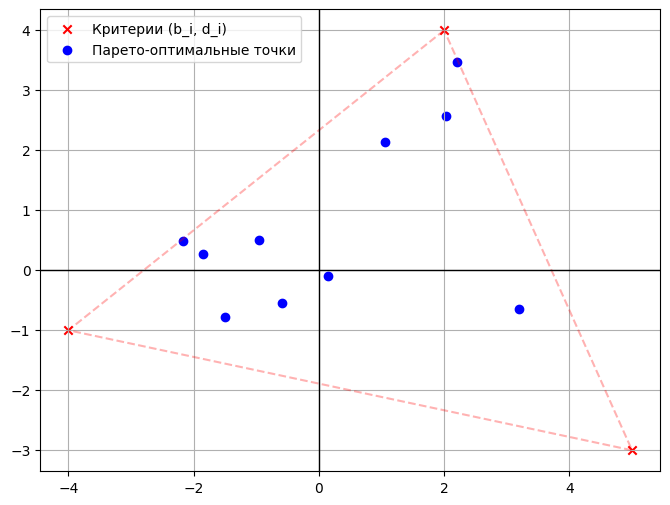

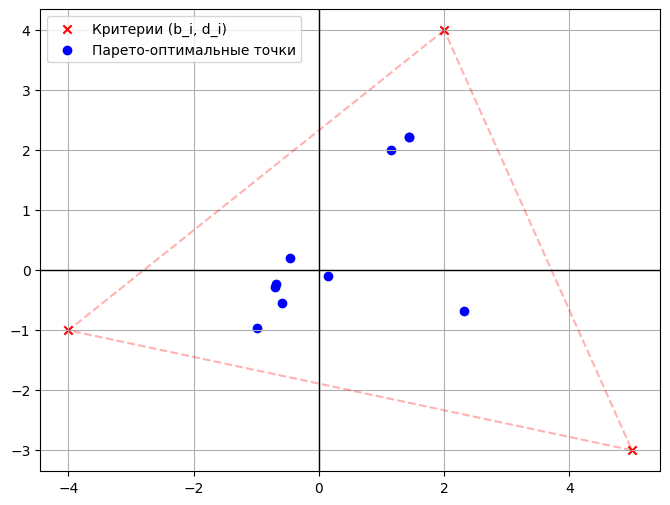

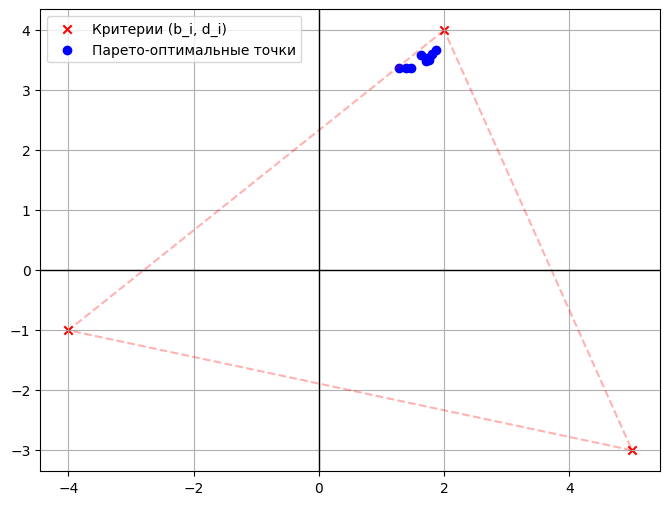

In [183]:
functions = [solve_additive_convolution, discrimination_method, successive_concessions]
weights = generate_weights()

for f in functions:
    pareto_points = calculate_pareto_points(weights, f)
    visualize(pareto_points)